In [154]:
from IPython import display

In [155]:
try:
    import nbformat
except:
    !pip install nbformat
display.clear_output()

+ action: train_feat01
+ feat_path: ../../exps/featbase_07112025/data.npz
+ seed: 42
+ exp_dir: d:\dai_hoc\nam3\HK5\ML\LAB_GROUP\Challenge_2_House_Price\process\exps
+ exp_name: train_07112025
+ data_dir: d:\dai_hoc\nam3\HK5\ML\LAB_GROUP\Challenge_2_House_Price\data
+ verbose: True
+ save_dir: d:\dai_hoc\nam3\HK5\ML\LAB_GROUP\Challenge_2_House_Price\process\exps\train_07112025
---------- information ----------
train-col: {'Fireplaces', 'BsmtFullBath', 'BsmtFinType2', 'ScreenPorch', 'TotRmsAbvGrd', 'PavedDrive', 'CentralAir', 'GarageQual', 'Utilities', 'GarageFinish', 'MasVnrType', 'Heating', 'GarageType', 'RoofMatl', 'MSSubClass', 'Id', 'HalfBath', 'BsmtFinSF1', 'Condition2', 'RoofStyle', 'ExterQual', 'SaleType', 'BldgType', 'BsmtExposure', 'BsmtFinSF2', 'LowQualFinSF', 'MoSold', 'GarageYrBlt', 'OpenPorchSF', 'GarageCars', 'Condition1', 'BsmtUnfSF', 'BsmtQual', 'BsmtHalfBath', 'PoolQC', 'MSZoning', 'LotArea', 'BsmtCond', 'Exterior1st', 'PoolArea', 'LotShape', 'OverallCond', '1stFlrSF',

<Figure size 1000x600 with 0 Axes>

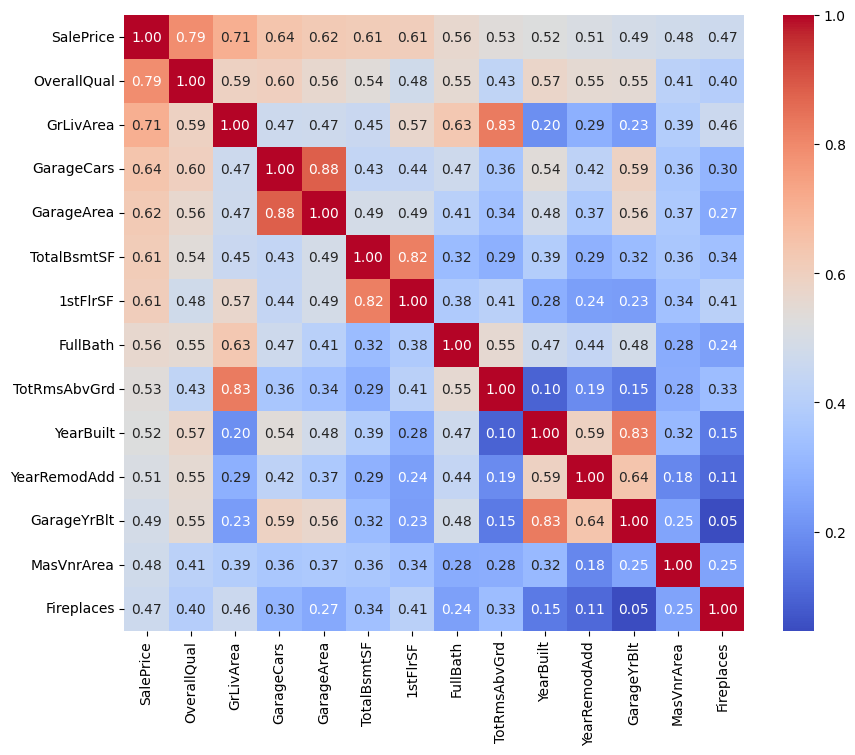

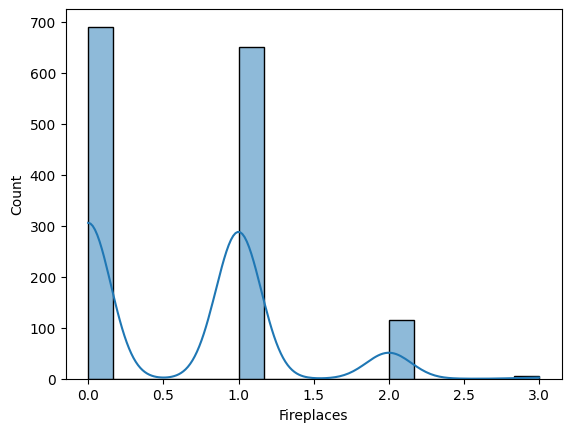


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Encoding column: BsmtExposure
Encoding column: BsmtFinType1
Encoding column: BsmtQual
Encoding column: ExterQual
Encoding column: Exterior1st
Encoding column: Exterior2nd
Encoding column: Foundation
Encoding column: GarageFinish
Encoding column: GarageType
Encoding column: HeatingQC
Encoding column: HouseStyle
Encoding column: KitchenQual
Encoding column: LotConfig
Encoding column: LotShape
Encoding column: MSZoning
Encoding column: RoofStyle
Encoding column: SaleCondition
Runing ... [train_feat01]
Column LotFrontage: 259 missing values
Column Alley: 1369 missing values
Column MasVnrType: 872 missing values
Column MasVnrArea: 8 missing values
Column BsmtQual: 37 missing values
Column BsmtCond: 37 missing values
Column BsmtExposure: 38 missing values
Column BsmtFinType1: 37 missing values
Column BsmtFinType2: 38 missing values
Column Electrical: 1 missing values
Column FireplaceQu: 690 missing values
Column GarageType: 81 missing values
Column GarageYrBlt: 81 missing values
Column Garag

In [156]:
%run ../model/train.ipynb

In [157]:
!jupyter nbconvert  ../model/train.ipynb --to html 

[NbConvertApp] Converting notebook ../model/train.ipynb to html
C:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 720987 bytes to ..\model\train.html


# Import lib


In [158]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve
import joblib

data = np.load("../../exps/train_07112025/data.npz", allow_pickle=True)

In [159]:
with np.load('../../exps/train_07112025/data.npz') as z:
    print(z.files)          # shows the list of keys present

['train_data', 'test_data', 'train_columns', 'test_columns']


In [160]:
data['train_columns']

array(['LotShape', 'Neighborhood', 'OverallQual', 'YearBuilt',
       'YearRemodAdd', 'RoofStyle', 'MasVnrArea', 'ExterQual',
       'Foundation', 'BsmtQual', 'BsmtExposure', 'TotalBsmtSF',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', 'GrLivArea',
       'FullBath', 'KitchenQual', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars',
       'GarageArea', 'PavedDrive', 'SaleCondition', 'HouseAge',
       'IsRemodeled', 'RemodeledSinceBuilt', 'TotalBath', 'GarageAge',
       'Output'], dtype=object)

In [161]:
len(data['train_columns'])

34

In [162]:
# Lấy dữ liệu train và test
df_train = pd.DataFrame(data = data['train_data'], columns= data['train_columns'])
df_test = pd.DataFrame(data['test_data'], columns=df_train.drop(columns=['Output']).columns)


In [163]:
df_train

,LotShape,Neighborhood,OverallQual,YearBuilt,YearRemodAdd,RoofStyle,MasVnrArea,ExterQual,Foundation,BsmtQual,...,GarageCars,GarageArea,PavedDrive,SaleCondition,HouseAge,IsRemodeled,RemodeledSinceBuilt,TotalBath,GarageAge,Output
0,-0.757723,0.323832,0.148937,1.050994,0.878668,-0.504727,0.514104,-1.052302,-0.951166,-0.643519,...,0.311725,0.111928,-0.28142,-0.423278,-1.043259,-0.954460,-0.555742,1.642256,-1.044790,208500.0
1,-0.757723,0.317797,0.148937,0.156734,-0.429577,-0.504727,-0.570750,0.689604,0.403666,-0.643519,...,0.311725,0.111928,-0.28142,-0.423278,-0.183465,-0.954460,-0.555742,0.368581,-0.170408,181500.0
2,1.329589,0.323832,0.148937,0.984752,0.830215,-0.504727,0.325915,-1.052302,-0.951166,-0.643519,...,0.311725,1.331442,-0.28142,-0.423278,-0.977121,1.047712,-0.514873,1.642256,-0.977530,223500.0
3,1.329589,0.536754,0.148937,-1.863632,-0.720298,-0.504727,-0.570750,0.689604,1.758497,0.922377,...,1.650307,1.331442,-0.28142,2.418035,1.800676,1.047712,1.692084,-0.268257,1.914657,140000.0
4,1.329589,2.578465,0.148937,0.951632,0.733308,-0.504727,1.366489,-1.052302,-0.951166,-0.643519,...,1.650307,1.331442,-0.28142,-0.423278,-0.944052,-0.954460,-0.555742,1.642256,-0.943900,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,-0.757723,0.227578,0.148937,0.918511,0.733308,-0.504727,-0.570750,0.689604,-0.951166,-0.643519,...,0.311725,0.111928,-0.28142,-0.423278,-0.944052,1.047712,-0.514873,0.368581,-0.910269,175000.0
1456,-0.757723,0.156242,0.148937,0.222975,0.151865,-0.504727,0.087911,0.689604,0.403666,-0.643519,...,0.311725,0.111928,-0.28142,-0.423278,-0.150396,1.047712,-0.147046,1.005418,-0.237668,210000.0
1457,-0.757723,0.536754,0.148937,-1.002492,1.024029,-0.504727,-0.570750,-2.794208,3.113329,0.922377,...,-1.026858,-1.107586,-0.28142,-0.423278,1.073157,1.047712,2.100780,-0.268257,1.006645,266500.0
1458,-0.757723,-0.651439,0.148937,-0.704406,0.539493,1.588743,-0.570750,0.689604,0.403666,0.922377,...,-1.026858,-1.107586,-0.28142,-0.423278,0.775536,1.047712,1.324258,-0.268257,0.703974,142125.0


In [164]:
df_train.isna().sum().sum()

np.int64(0)

In [165]:
df_test

,LotShape,Neighborhood,OverallQual,YearBuilt,YearRemodAdd,RoofStyle,MasVnrArea,ExterQual,Foundation,BsmtQual,...,GarageFinish,GarageCars,GarageArea,PavedDrive,SaleCondition,HouseAge,IsRemodeled,RemodeledSinceBuilt,TotalBath,GarageAge
0,-0.757723,-0.651439,0.148937,-0.340077,-1.156380,-0.504727,-0.570750,0.689604,0.403666,0.922377,...,-0.950313,-1.026858,1.331442,-0.28142,-0.423278,0.411777,-0.954460,-0.555742,-1.541932,0.334043
1,1.329589,-0.651439,0.148937,-0.439440,-1.301740,1.588743,0.027027,0.689604,0.403666,0.922377,...,-0.950313,-1.026858,-1.107586,-0.28142,-0.423278,0.510984,-0.954460,-0.555742,-0.905095,0.434934
2,1.329589,0.227578,0.148937,0.852269,0.636400,-0.504727,-0.570750,0.689604,-0.951166,-0.643519,...,1.514086,0.311725,0.111928,-0.28142,-0.423278,-0.778707,1.047712,-0.514873,0.368581,-0.843009
3,1.329589,0.227578,0.148937,0.885390,0.636400,-0.504727,-0.460051,0.689604,-0.951166,0.922377,...,1.514086,0.311725,0.111928,-0.28142,-0.423278,-0.811776,-0.954460,-0.555742,0.368581,-0.876639
4,1.329589,1.514181,0.148937,0.686666,0.345679,-0.504727,-0.570750,-1.052302,-0.951166,-0.643519,...,0.281887,0.311725,0.111928,-0.28142,-0.423278,-0.613362,-0.954460,-0.555742,-0.268257,-0.674859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,-0.757723,-0.650846,-2.569160,-0.041991,-0.720298,-0.504727,-0.570750,0.689604,0.403666,0.922377,...,-0.950313,-2.365440,-2.327100,-0.28142,-0.423278,-0.018120,-0.954460,-0.555742,-0.905095,0.031373
1455,-0.757723,-0.650846,-2.569160,-0.041991,-0.720298,-0.504727,-0.570750,0.689604,0.403666,0.922377,...,-0.950313,-1.026858,-1.107586,-0.28142,2.418035,-0.018120,-0.954460,-0.555742,-0.905095,0.031373
1456,-0.757723,-0.432340,0.148937,-0.373198,0.539493,-0.504727,-0.570750,0.689604,0.403666,0.922377,...,-0.950313,0.311725,0.111928,-0.28142,2.418035,0.312570,1.047712,0.915562,-0.268257,0.367673
1457,-0.757723,-0.432340,0.148937,0.686666,0.345679,-0.504727,-0.570750,0.689604,-0.951166,-0.643519,...,-0.950313,-2.365440,-2.327100,-0.28142,-0.423278,-0.745638,-0.954460,-0.555742,-0.905095,-0.708489


In [166]:
df_test.isna().sum().sum()

np.int64(0)

In [167]:
X_train = df_train.drop(columns=['Output'], axis=1)
y_train = df_train['Output']

In [168]:
X_test = df_test

# Linear Regression


In [169]:
# Import thư viện
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# Tạo pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

# Thiết lập hyperparameters
param_grid = {
    'linear__fit_intercept': [True, False],
    'linear__positive': [True, False],
    'linear__copy_X': [True]
}

# Sử dụng K-Fold (không stratified vì là regression)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Custom scorer để đánh giá nhiều metrics
def custom_scorer(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

# Grid Search với multiple scoring metrics
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring={
        'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
        'neg_mean_absolute_error': 'neg_mean_absolute_error', 
        'r2': 'r2'
    },
    refit='r2',  # Chọn metric để chọn best model
    n_jobs=-1,
    verbose=1
)

# Train model
print("\nBắt đầu training với GridSearch...")
grid_search.fit(X_train, y_train)

# Kết quả
print("\nBest parameters:", grid_search.best_params_)
print("Best cross-validation R2 score: {:.4f}".format(grid_search.best_score_))

# Lấy tất cả kết quả cross-validation
cv_results = grid_search.cv_results_
print("\nCross-validation results:")
for i in range(len(cv_results['params'])):
    print(f"\nParams: {cv_results['params'][i]}")
    print(f"  RMSE: {-cv_results['mean_test_neg_root_mean_squared_error'][i]:.4f} "
          f"(+/- {cv_results['std_test_neg_root_mean_squared_error'][i]:.4f})")
    print(f"  MAE: {-cv_results['mean_test_neg_mean_absolute_error'][i]:.4f} "
          f"(+/- {cv_results['std_test_neg_mean_absolute_error'][i]:.4f})")
    print(f"  R2: {cv_results['mean_test_r2'][i]:.4f} "
          f"(+/- {cv_results['std_test_r2'][i]:.4f})")


Bắt đầu training với GridSearch...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best parameters: {'linear__copy_X': True, 'linear__fit_intercept': True, 'linear__positive': False}
Best cross-validation R2 score: 0.7995

Cross-validation results:

Params: {'linear__copy_X': True, 'linear__fit_intercept': True, 'linear__positive': True}
  RMSE: 36192.1446 (+/- 3689.4109)
  MAE: 23821.2155 (+/- 1305.7887)
  R2: 0.7869 (+/- 0.0528)

Params: {'linear__copy_X': True, 'linear__fit_intercept': True, 'linear__positive': False}
  RMSE: 35026.0690 (+/- 4245.2909)
  MAE: 23177.2550 (+/- 1332.6198)
  R2: 0.7995 (+/- 0.0580)

Params: {'linear__copy_X': True, 'linear__fit_intercept': False, 'linear__positive': True}
  RMSE: 184401.5694 (+/- 1536.7506)
  MAE: 181150.9023 (+/- 1432.2917)
  R2: -4.4955 (+/- 0.7121)

Params: {'linear__copy_X': True, 'linear__fit_intercept': False, 'linear__positive': False}
  RMSE: 184199.6250 (+/- 903.1913)
  MAE: 181206.7359 (+/- 802.3671)
  R2: -4.485

In [170]:
# Lưu model tốt nhất
best_model_lr = grid_search.best_estimator_

# Đánh giá trên tập train
y_pred_train = best_model_lr.predict(X_train)

# Tính các metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print(f"\n=== KẾT QUẢ TRÊN TRAINING SET ===")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}") 
print(f"R2 Score: {train_r2:.4f}")


=== KẾT QUẢ TRÊN TRAINING SET ===
RMSE: 33398.6213
MAE: 22308.3943
R2 Score: 0.8231


## Dump mô hình linear regression


In [171]:
import os

# Ensure models directory exists
models_dir = os.path.join('../../exps', 'train_07112025', 'models')
os.makedirs(models_dir, exist_ok=True)

# Lưu model LinearRegression
file_path = os.path.join(models_dir, 'linear_regression_model.pkl')
joblib.dump(best_model_lr, file_path)
print(f"Model đã được lưu bằng joblib: {file_path}")

# Tham số
feature_names = X_train.columns.tolist()
scaler = best_model_lr.named_steps['scaler']

# Lưu nhiều objects cùng lúc 
pkg_path = os.path.join(models_dir, 'linear_model_package.pkl')
joblib.dump({
    'model': best_model_lr,
    'feature_names': feature_names,
    'scaler': scaler,
    'training_date': '2025-11-03',
    'metrics': {
        'rmse': train_rmse,
        'mae': train_mae,
        'r2': train_r2
    }
}, pkg_path)
print(f"Package đã được lưu: {pkg_path}")

# Load lại model
loaded_model = joblib.load(file_path)

# Kiểm tra model đã load
print("\nKiểm tra model đã load:")
y_pred_loaded = loaded_model.predict(X_train)
loaded_r2 = r2_score(y_train, y_pred_loaded)
print(f"R2 score của model đã load: {loaded_r2:.4f}")

Model đã được lưu bằng joblib: ../../exps\train_07112025\models\linear_regression_model.pkl
Package đã được lưu: ../../exps\train_07112025\models\linear_model_package.pkl

Kiểm tra model đã load:
R2 score của model đã load: 0.8231


## Tạo file submission.csv


# DecisionTreeRegressor


In [172]:
# Import thư viện
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor 
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# Tạo pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeRegressor(random_state=42))
])

# Thiết lập hyperparameters
param_grid = {
    'dt__max_depth': [3, 5, 7, 10, None],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 4],
    'dt__max_features': ['sqrt', 'log2', None]
}

# Sử dụng K-Fold (không stratified vì là regression) 
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search với multiple scoring metrics
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring={
        'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
        'neg_mean_absolute_error': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    refit='r2',  # Chọn metric để chọn best model
    n_jobs=-1,
    verbose=1
)

# Train model
print("\nBắt đầu training với GridSearch...")
grid_search.fit(X_train, y_train)

# Kết quả
print("\nBest parameters:", grid_search.best_params_)
print("Best cross-validation R2 score: {:.4f}".format(grid_search.best_score_))

# Lấy tất cả kết quả cross-validation
cv_results = grid_search.cv_results_
print("\nCross-validation results:")
for i in range(len(cv_results['params'])):
    print(f"\nParams: {cv_results['params'][i]}")
    print(f"  RMSE: {-cv_results['mean_test_neg_root_mean_squared_error'][i]:.4f} "
          f"(+/- {cv_results['std_test_neg_root_mean_squared_error'][i]:.4f})")
    print(f"  MAE: {-cv_results['mean_test_neg_mean_absolute_error'][i]:.4f} "
          f"(+/- {cv_results['std_test_neg_mean_absolute_error'][i]:.4f})")
    print(f"  R2: {cv_results['mean_test_r2'][i]:.4f} "
          f"(+/- {cv_results['std_test_r2'][i]:.4f})")


Bắt đầu training với GridSearch...
Fitting 5 folds for each of 135 candidates, totalling 675 fits

Best parameters: {'dt__max_depth': None, 'dt__max_features': 'sqrt', 'dt__min_samples_leaf': 4, 'dt__min_samples_split': 2}
Best cross-validation R2 score: 0.7403

Cross-validation results:

Params: {'dt__max_depth': 3, 'dt__max_features': 'sqrt', 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
  RMSE: 50631.6965 (+/- 2292.9201)
  MAE: 34620.5423 (+/- 2031.0766)
  R2: 0.5876 (+/- 0.0445)

Params: {'dt__max_depth': 3, 'dt__max_features': 'sqrt', 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 5}
  RMSE: 50631.6965 (+/- 2292.9201)
  MAE: 34620.5423 (+/- 2031.0766)
  R2: 0.5876 (+/- 0.0445)

Params: {'dt__max_depth': 3, 'dt__max_features': 'sqrt', 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 10}
  RMSE: 50631.6965 (+/- 2292.9201)
  MAE: 34620.5423 (+/- 2031.0766)
  R2: 0.5876 (+/- 0.0445)

Params: {'dt__max_depth': 3, 'dt__max_features': 'sqrt', 'dt__min_samples_leaf': 2, 

In [173]:
# Lưu model tốt nhất
best_model_dt = grid_search.best_estimator_
joblib.dump(best_model_dt, '../../exps/train_07112025/models/decision_tree_model.pkl')

# Đánh giá trên tập train
y_pred_train = best_model_dt.predict(X_train)

# Tính các metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print(f"\n=== KẾT QUẢ TRÊN TRAINING SET ===")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}") 
print(f"R2 Score: {train_r2:.4f}")


=== KẾT QUẢ TRÊN TRAINING SET ===
RMSE: 28142.5367
MAE: 17503.7868
R2 Score: 0.8744


# Dump mô hình DecisionTreeRegressor


In [174]:

# Dump mô hình và thông tin liên quan
import joblib

# Lưu model DecisionTree
joblib.dump(best_model_dt, '../../exps/train_07112025/models/decision_tree_model.pkl')
print("Model đã được lưu bằng joblib")

# Tham số
feature_names = X_train.columns.tolist()
scaler = best_model_dt.named_steps['scaler']

# Lưu nhiều objects cùng lúc 
joblib.dump({
    'model': best_model_dt,
    'feature_names': feature_names,
    'scaler': scaler,
    'training_date': '2025-10-23',
    'metrics': {
        'rmse': train_rmse,
        'mae': train_mae,
        'r2': train_r2
    }
}, '../../exps/train_07112025/models/decision_tree_package.pkl')

# Load lại model
loaded_model = joblib.load('../../exps/train_07112025/models/decision_tree_model.pkl')

# Kiểm tra model đã load
print("\nKiểm tra model đã load:")
y_pred_loaded = loaded_model.predict(X_train)
loaded_r2 = r2_score(y_train, y_pred_loaded)
print(f"R2 score của model đã load: {loaded_r2:.4f}")

Model đã được lưu bằng joblib

Kiểm tra model đã load:
R2 score của model đã load: 0.8744


## Tạo file submission.csv


# RandomForestRegressor


In [175]:
# Import thư viện
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# Tạo pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=42))
])

# Thiết lập hyperparameters 
# Sửa param_grid để tránh các combination có vấn đề
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, 30, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 0.8, 0.9],  # Thay 'auto' bằng giá trị cụ thể
    'rf__bootstrap': [True]  # Chỉ dùng bootstrap=True để tránh lỗi
}

# Sử dụng K-Fold
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search với multiple scoring metrics
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring={
        'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
        'neg_mean_absolute_error': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    refit='r2',
    n_jobs=-1,
    verbose=1
)

# Train model
print("\nBắt đầu training với GridSearch...")
grid_search.fit(X_train, y_train)

# Kết quả
print("\nBest parameters:", grid_search.best_params_)
print("Best cross-validation R2 score: {:.4f}".format(grid_search.best_score_))

# Lấy tất cả kết quả cross-validation
cv_results = grid_search.cv_results_
print("\nCross-validation results:")
for i in range(len(cv_results['params'])):
    print(f"\nParams: {cv_results['params'][i]}")
    print(f"  RMSE: {-cv_results['mean_test_neg_root_mean_squared_error'][i]:.4f} "
          f"(+/- {cv_results['std_test_neg_root_mean_squared_error'][i]:.4f})")
    print(f"  MAE: {-cv_results['mean_test_neg_mean_absolute_error'][i]:.4f} "
          f"(+/- {cv_results['std_test_neg_mean_absolute_error'][i]:.4f})")
    print(f"  R2: {cv_results['mean_test_r2'][i]:.4f} "
          f"(+/- {cv_results['std_test_r2'][i]:.4f})")

# Lưu model tốt nhất và đánh giá
best_model_rf = grid_search.best_estimator_
y_pred_train = best_model_rf.predict(X_train)

# Tính các metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print(f"\n=== KẾT QUẢ TRÊN TRAINING SET ===")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}") 
print(f"R2 Score: {train_r2:.4f}")

# Dump mô hình và thông tin liên quan
# Lưu model RandomForest
joblib.dump(best_model_rf, '../../exps/train_07112025/models/random_forest_model.pkl')
print("Model đã được lưu bằng joblib")

# Tham số
feature_names = X_train.columns.tolist()
scaler = best_model_rf.named_steps['scaler']

# Lưu nhiều objects cùng lúc 
joblib.dump({
    'model': best_model_rf,
    'feature_names': feature_names,
    'scaler': scaler,
    'training_date': '2025-11-06',
    'metrics': {
        'rmse': train_rmse,
        'mae': train_mae,
        'r2': train_r2
    }
}, '../../exps/train_07112025/models/random_forest_package.pkl')

# Load lại model
loaded_model = joblib.load('../../exps/train_07112025/models/random_forest_model.pkl')

# Kiểm tra model đã load
print("\nKiểm tra model đã load:")
y_pred_loaded = loaded_model.predict(X_train)
loaded_r2 = r2_score(y_train, y_pred_loaded)
print(f"R2 score của model đã load: {loaded_r2:.4f}")


Bắt đầu training với GridSearch...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best parameters: {'rf__bootstrap': True, 'rf__max_depth': 30, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Best cross-validation R2 score: 0.8559

Cross-validation results:

Params: {'rf__bootstrap': True, 'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
  RMSE: 30238.7055 (+/- 3607.7871)
  MAE: 18937.9503 (+/- 1476.2030)
  R2: 0.8506 (+/- 0.0414)

Params: {'rf__bootstrap': True, 'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
  RMSE: 30020.8998 (+/- 3649.9133)
  MAE: 18831.2299 (+/- 1424.8255)
  R2: 0.8526 (+/- 0.0415)

Params: {'rf__bootstrap': True, 'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estim

In [176]:
# Lưu model tốt nhất và đánh giá
best_model_rf = grid_search.best_estimator_
y_pred_train = best_model_rf.predict(X_train)

# Tính các metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print(f"\n=== KẾT QUẢ TRÊN TRAINING SET ===")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}") 
print(f"R2 Score: {train_r2:.4f}")


=== KẾT QUẢ TRÊN TRAINING SET ===
RMSE: 11042.1951
MAE: 6737.8310
R2 Score: 0.9807


# Dump mô hình RandomForestRegressor


In [177]:
# Dump mô hình và thông tin liên quan
# Lưu model RandomForest
joblib.dump(best_model_rf, '../../exps/train_07112025/models/random_forest_model.pkl')
print("Model đã được lưu bằng joblib")

# Tham số
feature_names = X_train.columns.tolist()
scaler = best_model_rf.named_steps['scaler']

# Lưu nhiều objects cùng lúc 
joblib.dump({
    'model': best_model_rf,
    'feature_names': feature_names,
    'scaler': scaler,
    'training_date': '2025-11-03',
    'metrics': {
        'rmse': train_rmse,
        'mae': train_mae,
        'r2': train_r2
    }
}, '../../exps/train_07112025/models/random_forest_package.pkl')

# Load lại model
loaded_model = joblib.load('../../exps/train_07112025/models/random_forest_model.pkl')

# Kiểm tra model đã load
print("\nKiểm tra model đã load:")
y_pred_loaded = loaded_model.predict(X_train)
loaded_r2 = r2_score(y_train, y_pred_loaded)
print(f"R2 score của model đã load: {loaded_r2:.4f}")

Model đã được lưu bằng joblib

Kiểm tra model đã load:
R2 score của model đã load: 0.9807


# Chọn ra mô hình tối ưu


In [178]:
import pandas as pd
import numpy as np
import joblib
import os

def create_submissions(test_data, models_dir, output_dir):
    """
    Create submission files for multiple models
    
    Args:
        test_data: DataFrame containing test data
        models_dir: Directory containing saved models
        output_dir: Directory to save submission files
    """
    
    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # List of models to create submissions for
    models = {
        'linear': 'linear_regression_model.pkl',
        'decision_tree': 'decision_tree_model.pkl', 
        'random_forest': 'random_forest_model.pkl'
    }

    df_full_test = pd.read_csv('../../../data/test.csv')
    id_col = df_full_test['Id'].to_list()
    
    for model_name, model_file in models.items():
        try:
            # Load model
            model_path = os.path.join(models_dir, model_file)
            model = joblib.load(model_path)
            
            
            # Make predictions
            predictions = model.predict(test_data)
            
            # Create submission DataFrame
            submission = pd.DataFrame({
                'Id': id_col,
                'SalePrice': predictions
            })
            
            # Save submission file
            output_file = os.path.join(output_dir, f'submission_{model_name}.csv')
            submission.to_csv(output_file, index=False)
            
            print(f"Created submission for {model_name}")
            print(f"Saved to: {output_file}")
            print(f"Predictions summary:")
            print(submission['SalePrice'].describe())
            print("-" * 50)
            
        except Exception as e:
            print(f"Error creating submission for {model_name}: {str(e)}")

def main():
    # Load test data
    data = np.load("../../exps/train_07112025/data.npz", allow_pickle=True)
    X_test = pd.DataFrame(data['test_data'], columns=data['test_columns'])
    
    # Define directories
    models_dir = "../../exps/train_07112025/models"
    output_dir = "../../exps/train_07112025/submissions"
    
    # Create submissions
    create_submissions(X_test, models_dir, output_dir)
    
    # Compare predictions
    submissions = {}
    for model in ['linear', 'decision_tree', 'random_forest']:
        file_path = os.path.join(output_dir, f'submission_{model}.csv')
        if os.path.exists(file_path):
            submissions[model] = pd.read_csv(file_path)
    
    if len(submissions) > 1:
        print("\nPredictions Correlation Matrix:")
        correlations = pd.DataFrame()
        for model1 in submissions:
            for model2 in submissions:
                corr = submissions[model1]['SalePrice'].corr(
                    submissions[model2]['SalePrice']
                )
                correlations.loc[model1, model2] = corr
        print(correlations)

if __name__ == "__main__":
    main()

Created submission for linear
Saved to: ../../exps/train_07112025/submissions\submission_linear.csv
Predictions summary:
count      1459.000000
mean     178835.355403
std       74771.936284
min       15608.194608
25%      127647.062809
50%      164037.276969
75%      213998.161849
max      480674.281709
Name: SalePrice, dtype: float64
--------------------------------------------------
Created submission for decision_tree
Saved to: ../../exps/train_07112025/submissions\submission_decision_tree.csv
Predictions summary:
count      1459.000000
mean     178397.833623
std       75340.734133
min       53402.750000
25%      130100.000000
50%      157541.666667
75%      212491.200000
max      546040.666667
Name: SalePrice, dtype: float64
--------------------------------------------------
Created submission for random_forest
Saved to: ../../exps/train_07112025/submissions\submission_random_forest.csv
Predictions summary:
count      1459.000000
mean     178952.728158
std       71089.762372
min   